# Module A: B+ Tree Database Engine Demonstration
First, we initialize a table with `order=4` so we can easily see how nodes split and the tree balances itself.

In [1]:
from db_manager import DatabaseManager
from IPython.display import display

# 1. Initialize Database and Table
db = DatabaseManager()
db.create_database("company_db")
db.create_table(
    db_name="company_db",
    table_name="employees",
    schema={"emp_id": int, "name": str, "department": str},
    order=4,  # Order 4 means a max of 3 keys per node.
    search_key="emp_id"
)

table, _ = db.get_table("company_db", "employees")
print("Database 'company_db' and Table 'employees' initialized.")

Database 'company_db' and Table 'employees' initialized.


### 1. Schema Validation
Before reaching the B+ Tree, the `Table` class checks if the input matches the defined schema. We try inserting a string where an integer is expected.

In [2]:
success, msg = table.insert({"emp_id": "TEN", "name": "Alice", "department": "HR"})
print(f"Insertion Status: {'Success' if success else 'Failure'} | Message: {msg}")

Insertion Status: Failure | Message: Invalid record schema


### 2. Insertions
Now we insert three valid records. Because the order is 4, the root node can hold exactly 3 keys before it gets full.

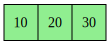

In [3]:
table.insert({"emp_id": 10, "name": "Alice", "department": "HR"})
table.insert({"emp_id": 20, "name": "Bob", "department": "Engineering"})
table.insert({"emp_id": 30, "name": "Charlie", "department": "Sales"})

display(table.data.visualize_tree())

### 3. Node Split
When we insert a fourth record, the root node overflows. It splits into two leaf nodes and promotes the middle key to create a new internal root node.

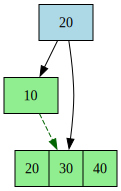

In [4]:
table.insert({"emp_id": 40, "name": "Diana", "department": "Engineering"})

display(table.data.visualize_tree())

### 4. Scaling the Tree
If we insert a few more records, more splits are triggered. The internal nodes store the routing keys, and the leaf nodes stay connected horizontally for range queries.

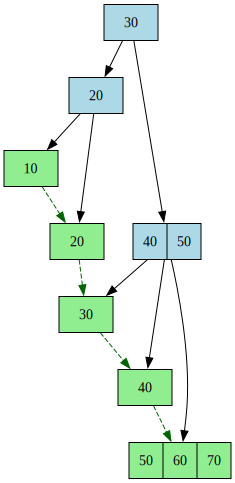

In [5]:
table.insert({"emp_id": 50, "name": "Evan", "department": "Marketing"})
table.insert({"emp_id": 60, "name": "Fiona", "department": "Sales"})
table.insert({"emp_id": 70, "name": "George", "department": "HR"})

display(table.data.visualize_tree())

### 5. Search and Range Queries
Search runs in $O(\log n)$ time, and the range query uses the linked leaf nodes to find the answer in $O(\log n + k)$ time.

In [6]:
print("Search (ID: 40)")
print(table.get(40))

print()

print("Range Query:")
results = table.range_query(20, 50)
for key, record in results:
    print(f"ID: {key} | Name: {record['name']:<8} | Dept: {record['department']}")

Search (ID: 40)
{'emp_id': 40, 'name': 'Diana', 'department': 'Engineering'}

Range Query:
ID: 20 | Name: Bob      | Dept: Engineering
ID: 30 | Name: Charlie  | Dept: Sales
ID: 40 | Name: Diana    | Dept: Engineering
ID: 50 | Name: Evan     | Dept: Marketing


### 6. Updating Records and Primary Keys
First, we update Robert's department in-place. Then, we change his primary key from 20 to 25. The Table class handles the primary key change by safely deleting the old record and inserting the new one.

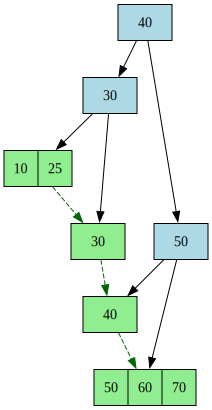

In [7]:
# In place update
table.update(20, {"emp_id": 20, "name": "Robert", "department": "Engineering Lead"})

# Primary key mutation
table.update(20, {"emp_id": 25, "name": "Robert", "department": "Engineering Lead"})

display(table.data.visualize_tree())

### 7. Deletion and Borrowing
Deleting ID 10 causes an underflow in the leftmost leaf node. The tree automatically fixes this by borrowing a key from its right sibling and updating the parent's routing key.

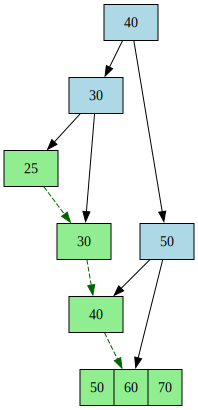

In [8]:
table.delete(10)

print("Tree after deleting ID 10 (triggers borrow):")
display(table.data.visualize_tree())

### 8. Deletion and Merging
If we delete IDs 30 and 40, borrowing isn't enough to fix the underflow. The tree merges the nodes together, which updates the internal routing structure.

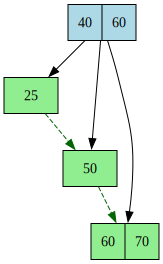

In [9]:
table.delete(30)
table.delete(40)

print("Tree after deleting ID 30 and 40 (triggers merge):")
display(table.data.visualize_tree())